In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_pickle("/content/drive/MyDrive/AI/AIA/2_CarPricesData (1).pkl")

In [3]:
df

,Age,KM,Weight,HP,MetColor,CC,Doors,Price
0,23.0,46986,1165.0,90,1,2000.0,3,13500
1,23.0,72937,1165.0,90,1,2000.0,3,13750
2,24.0,41711,1165.0,90,1,2000.0,3,13950
3,26.0,48000,1165.0,90,0,2000.0,3,14950
4,30.0,38500,1170.0,90,0,2000.0,3,13750
...,...,...,...,...,...,...,...,...
1431,69.0,20544,1025.0,86,1,1300.0,3,7500
1432,72.0,19000,1015.0,86,0,1300.0,3,10845
1433,71.0,17016,1015.0,86,0,1300.0,3,8500
1434,70.0,16916,1015.0,86,1,1300.0,3,7250


In [4]:
df.isnull().sum()

,0
Age,0
KM,0
Weight,0
HP,0
MetColor,0
CC,0
Doors,0
Price,0


In [5]:
df.groupby("Doors")['Weight'].max()

,Weight
Doors,
2,1115.0
3,1320.0
4,1160.0
5,1320.0


In [6]:
df.columns

Index(['Age', 'KM', 'Weight', 'HP', 'MetColor', 'CC', 'Doors', 'Price'], dtype='object')

In [7]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
df[['Age', 'KM', 'Weight', 'HP', 'CC']] = sc.fit_transform(df[['Age', 'KM', 'Weight', 'HP', 'CC']])
df.head()

,Age,KM,Weight,HP,MetColor,CC,Doors,Price
0,0.278481,0.193355,0.515625,0.170732,1,1.0,3,13500
1,0.278481,0.300149,0.515625,0.170732,1,1.0,3,13750
2,0.291139,0.171647,0.515625,0.170732,1,1.0,3,13950
3,0.316456,0.197528,0.515625,0.170732,0,1.0,3,14950
4,0.367089,0.158433,0.531250,0.170732,0,1.0,3,13750


<Axes: xlabel='Age'>

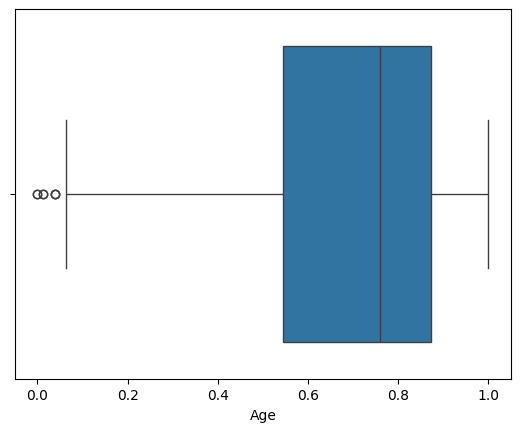

In [8]:
# Handling outliers
# Task

import seaborn as sns

sns.boxplot(x='Age',data=df)

In [9]:
# Spiting data
X = df.iloc[:,:-1]
y = df['Price']

In [10]:
X.shape

(1435, 7)

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,random_state=42)

In [12]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1076, 7)
(359, 7)
(1076,)
(359,)


In [13]:
1076/20

53.8

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1435 non-null   float64
 1   KM        1435 non-null   float64
 2   Weight    1435 non-null   float64
 3   HP        1435 non-null   float64
 4   MetColor  1435 non-null   int64  
 5   CC        1435 non-null   float64
 6   Doors     1435 non-null   int64  
 7   Price     1435 non-null   int64  
dtypes: float64(5), int64(3)
memory usage: 100.9 KB


In [15]:
df['Price'] = df['Price'].astype('float32')

In [16]:
y_train = y_train.astype('float32')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1435 non-null   float64
 1   KM        1435 non-null   float64
 2   Weight    1435 non-null   float64
 3   HP        1435 non-null   float64
 4   MetColor  1435 non-null   int64  
 5   CC        1435 non-null   float64
 6   Doors     1435 non-null   int64  
 7   Price     1435 non-null   float32
dtypes: float32(1), float64(5), int64(2)
memory usage: 95.3 KB


In [18]:
# Model building
from keras import Sequential
from keras.layers import Dense
import tensorflow as tf
from sklearn.metrics import r2_score

model = Sequential()
model.add(Dense(units=16,input_dim=7,kernel_initializer='he_uniform',activation='relu'))
model.add(Dense(units = 32,kernel_initializer='he_uniform',activation='relu'))
model.add(Dense(units=64,kernel_initializer='he_uniform',activation='relu'))
model.add(Dense(units=1,kernel_initializer='he_uniform'))

model.compile(loss='mean_squared_error',optimizer='adam', metrics=[tf.keras.metrics.R2Score()])
model.fit(x_train,y_train,batch_size=20,epochs=10,verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 124735368.0000 - r2_score: -9.0129
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 124610496.0000 - r2_score: -8.7350
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 122814536.0000 - r2_score: -8.4883
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 117137408.0000 - r2_score: -9.7025
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 101550656.0000 - r2_score: -7.9121
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 79310208.0000 - r2_score: -4.5607
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 45066820.0000 - r2_score: -2.3007
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21570556.0000 - r2_score: -0.7213
Epoch 9/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16089527.0000 - r2_score: -0.1548
Epoch 10/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14214066.0000 - r2_score: -0.1434


In [ ]:
# Do EDA and domain analysis
# Check if you have outliers
# Try other scaling option
# Increase the hidden layers
# train for more epochs---- 100

In [19]:
y_test = y_test.astype("float32")

In [20]:
model.evaluate(x_test,y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11901351.0000 - r2_score: -0.0551 


[13514748.0, -0.03222382068634033]

In [25]:
y_pred = model.predict(x_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [26]:
r2 = r2_score(y_test, y_pred)
r2

-0.03222370147705078

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np


In [29]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Mean Absolute Percentage Error
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

ACC=100-mape

print("MSE :", mse)
print("RMSE:", rmse)
print("MAPE:", mape, "%")
print("ACC",ACC)


MSE : 13514746.0
RMSE: 3676.240742932922
MAPE: 25.85531771183014 %
ACC 74.14468228816986
